#Le quartet d'Ancombe

Démonstration de l'importance de la représentation graphique des données lors de leur analyse, ainsi que l'influence des valeurs aberrantes et autres observations significatives sur les propriétés statistiques (sources : wikipedia)

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

## 1. Chargement des données

Le dataset est disponible directement via Seaborn ou depuis GitHub.

In [2]:
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/anscombe.csv' #récupération du fichier dans GitHub
df_anscombe = pd.read_csv(url)

## 2. Statistiques descriptives — le piège

In [3]:
df_anscombe.head() #Affiche les 5 premières lignes de l'ensemble des données

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33


In [4]:
df_anscombe.describe() # calcule les statistiques descriptives des colonnes numériques

,x,y
count,44.000000,44.000000
mean,9.000000,7.500682
std,3.198837,1.958925
min,4.000000,3.100000
25%,7.000000,6.117500
50%,8.000000,7.520000
75%,11.000000,8.747500
max,19.000000,12.740000


In [5]:
df_anscombe.dataset.unique() # liste des valeurs distinctes de la colonne dataset

array(['I', 'II', 'III', 'IV'], dtype=object)

In [6]:
df_anscombe.dataset.value_counts() #combien de fois chaque valeur apparait

,count
dataset,
I,11
II,11
III,11
IV,11


In [7]:
df_anscombe.groupby('dataset').describe() #Regroupe le dataframe puis applique la fonction describe

x                                               y            \
        count mean       std  min  25%  50%   75%   max count      mean   
dataset                                                                   
I        11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500909   
II       11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500909   
III      11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500000   
IV       11.0  9.0  3.316625  8.0  8.0  8.0   8.0  19.0  11.0  7.500909   

                                                   
              std   min    25%   50%   75%    max  
dataset                                            
I        2.031568  4.26  6.315  7.58  8.57  10.84  
II       2.031657  3.10  6.695  8.14  8.95   9.26  
III      2.030424  5.39  6.250  7.11  7.98  12.74  
IV       2.030579  5.25  6.170  7.04  8.19  12.50

In [8]:
df_anscombe.groupby('dataset').corr()

x         y
dataset                      
I       x  1.000000  0.816421
        y  0.816421  1.000000
II      x  1.000000  0.816237
        y  0.816237  1.000000
III     x  1.000000  0.816287
        y  0.816287  1.000000
IV      x  1.000000  0.816521
        y  0.816521  1.000000

Ces quatre datasets ont des propriétés statistiques quasi-identiques :
- Même moyenne de x et de y
- Même variance de x et de y
- Même corrélation entre x et y
- Même droite de régression

Et pourtant, **ils sont radicalement différents**.

## 3. Visualisation — la révélation

Les mêmes données, vues cette fois avec des yeux.

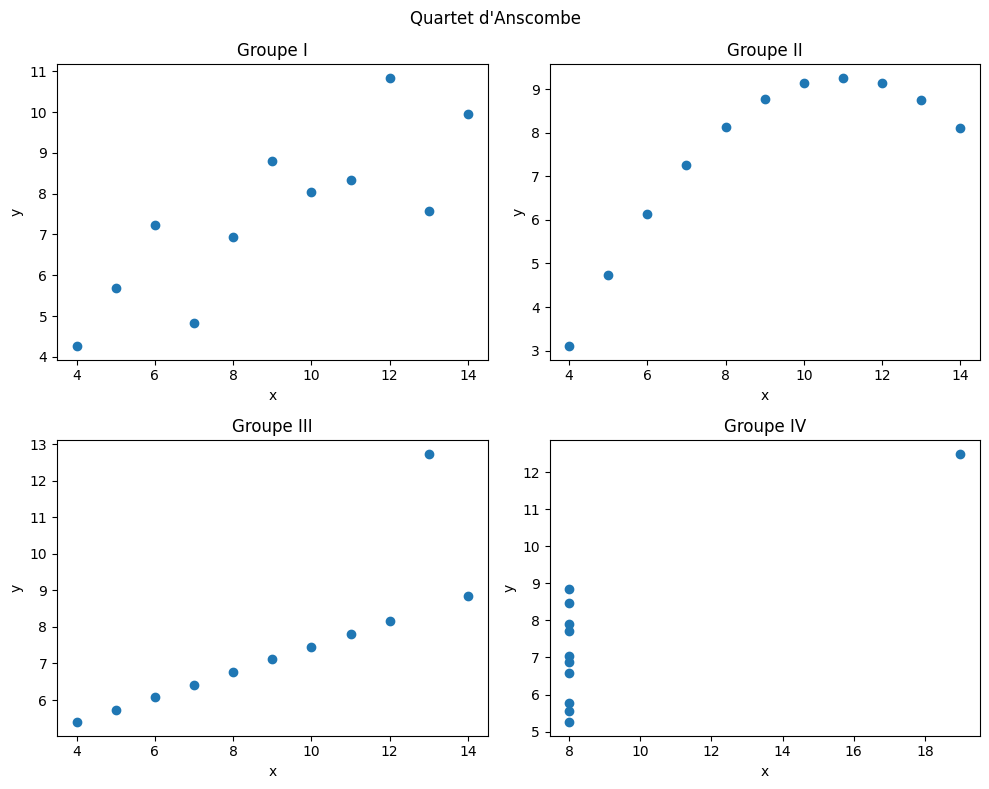

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8)) #Visualisation des 4 jeux pour vérifier les différences
groupes = ['I', 'II', 'III', 'IV']

for ax, groupe in zip(axes.flatten(), groupes):
    data = df_anscombe[df_anscombe['dataset'] == groupe]
    ax.scatter(data['x'], data['y'])
    ax.set_title(f'Groupe {groupe}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.suptitle('Quartet d\'Anscombe')
plt.tight_layout()
plt.show()

## 4. Analyse groupe par groupe

### Groupe I — Relation linéaire ✓
Le seul cas où une régression linéaire est appropriée. Les résidus sont aléatoires, pas de structure visible.

### Groupe II — Relation quadratique ✗ pour la linéaire
La relation est clairement non linéaire (parabole). Fitter une droite est une erreur de modélisation — le modèle linéaire est systématiquement faux sur tout l'intervalle.

### Groupe III — Outlier influent ✗
La relation serait parfaitement linéaire sans le point aberrant. Cet outlier tire la droite de régression vers lui et fausse l'ensemble des coefficients. **Décision à documenter : supprimer ou conserver ?**

### Groupe IV — Quasi-constante + outlier extrême ✗
Toutes les valeurs de x sont identiques (x=8) sauf une (x=19). La droite de régression est entièrement déterminée par ce seul point. Ce n'est pas une régression — c'est du bruit.

**Le quartet d'Anscombe montre que des datasets avec des statistiques descriptives quasi-identiques (même moyenne, même variance, même corrélation) peuvent avoir des structures radicalement différentes. La visualisation n'est donc pas optionnelle.**